# California housing → bracket-contract prices

Take a regression dataset, predict a **distribution** over house prices,
then price a ladder of binary contracts ("will this house sell above $X?")
against the forecast distribution.

This notebook builds the visual story behind
[`examples/housing_brackets.py`](../examples/housing_brackets.py):

1. Fit `EmpiricalDistribution` (baseline), `Ridge + GlobalResidual`, and
   `QuantileReg` inside a `ForecastPipeline` with k-fold CV.
2. Score them on distribution-level (CRPS, PIT) and contract-level
   (Brier, log-loss) metrics.
3. Plot what those numbers actually mean.
4. Run a wider **leaderboard** over many trainers and rank them.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import RidgeCV

warnings.filterwarnings(
    "ignore", message="X does not have valid feature names.*",
    category=UserWarning,
)

from bracketlearn.adapters import BracketLadder
from bracketlearn.baselines import EmpiricalDistribution
from bracketlearn.composite import LiftedForecaster
from bracketlearn.lift import GlobalResidual
from bracketlearn.pipeline import ForecastPipeline
from bracketlearn.score import pit
from bracketlearn.trainers import QuantileReg, SklearnPoint

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Data

California housing — sklearn-bundled, 20 640 rows, target is median house
value in units of $100k. We subsample to 4 000 rows for notebook speed.

In [2]:
data = fetch_california_housing()
X = np.asarray(data.data, dtype=float)
y = np.asarray(data.target, dtype=float)
rng = np.random.default_rng(0)
keep = rng.choice(X.shape[0], size=4000, replace=False)
X, y = X[keep], y[keep]
ids = np.arange(X.shape[0])
ts = ids.astype(float)
print(f"X shape: {X.shape}   y range: ${y.min()*100:.0f}k–${y.max()*100:.0f}k")

X shape: (4000, 8)   y range: $18k–$500k


## Bracket ladder

8 buckets spanning $50k–$500k. The pipeline's forecasts get priced
against this ladder as binary contracts ("price falls into bracket k?").

In [3]:
edges = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0])
ladder = BracketLadder(edges=edges)
bracket_labels = [f"${lo*100:.0f}–${hi*100:.0f}k"
                  for lo, hi in zip(edges[:-1], edges[1:], strict=True)]
print(f"{len(edges)-1} brackets covering ${edges[0]*100:.0f}k–${edges[-1]*100:.0f}k")

8 brackets covering $50k–$500k


## Fit the headline pipeline

Three stages: marginal-y **baseline**, a Ridge + Gaussian residual, and a
LightGBM quantile-regression forecast. The pipeline clones each stage
per fold (k-fold CV with shuffle) so the user's instances stay clean.

In [4]:
pipeline = ForecastPipeline(
    steps=[
        ("emp", EmpiricalDistribution()),
        ("ridge", LiftedForecaster(
            SklearnPoint(RidgeCV()), GlobalResidual(), name="ridge",
        )),
        ("qreg", QuantileReg(n_estimators=200, learning_rate=0.05, random_seed=0)),
    ],
    cv="kfold", n_folds=5, shuffle=True, random_state=0,
    refit_on_full=True,
)
result = pipeline.fit_predict(X, y, ids=ids, timestamps=ts)
print(result.to_table(y, metrics=["crps", "log_score", "pit"]))

stage              n_oof          crps     log_score      pit_mean       pit_std
--------------------------------------------------------------------------------
emp                 4000        0.6120        1.3754        0.4979        0.2925
ridge               4000        0.4048        2.5319        0.4769        0.2658
qreg                4000        0.2514       -0.4010        0.4820        0.3156


## Skill score vs the baseline

CRPSS = 1 − CRPS / CRPS_baseline. Positive = beats the marginal-y
floor; > 0.5 = strong.

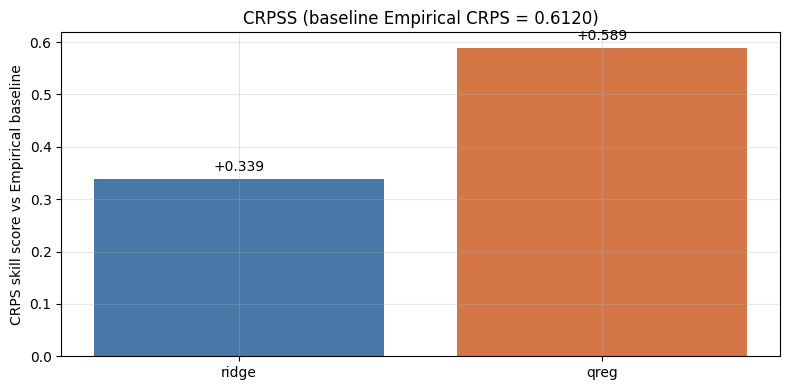

In [5]:
crps_scores = result.score(y, metrics=["crps"])
baseline = crps_scores["emp"]["crps"]
stage_names, skills, crps_vals = [], [], []
for stage, row in crps_scores.items():
    if stage == "emp":
        continue
    stage_names.append(stage)
    skills.append(1.0 - row["crps"] / baseline)
    crps_vals.append(row["crps"])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stage_names, skills, color=["#4878a8", "#d57646"])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("CRPS skill score vs Empirical baseline")
ax.set_title(f"CRPSS (baseline Empirical CRPS = {baseline:.4f})")
for bar, val in zip(bars, skills, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:+.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## PIT histogram

The Probability Integral Transform of the realized y under the forecast
CDF should be uniform on [0, 1] if the forecast is well-calibrated.
A U-shape = overconfident (forecasts too narrow); an inverted-U =
underconfident.

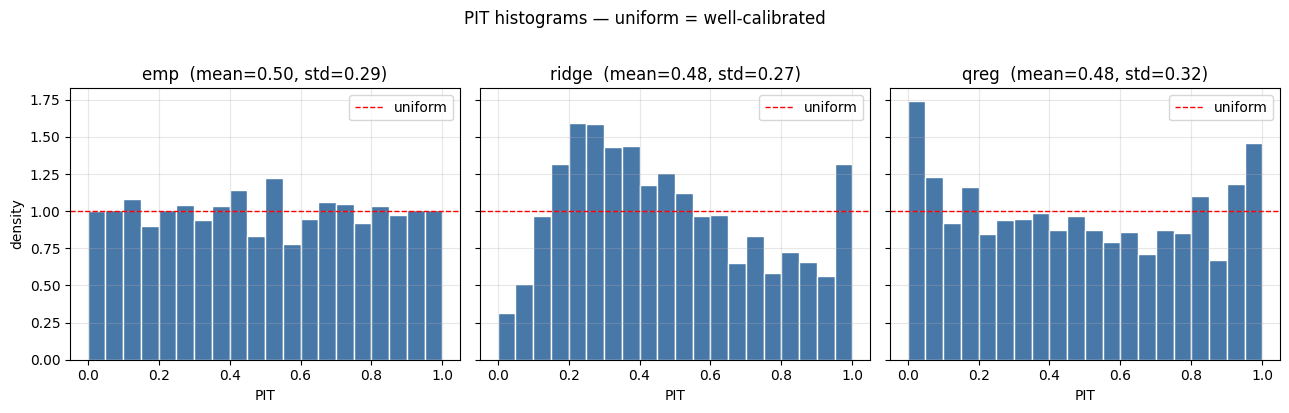

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, name in zip(axes, ["emp", "ridge", "qreg"], strict=True):
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    pit_vals = pit(dist, y_oof)
    ax.hist(pit_vals, bins=20, color="#4878a8", edgecolor="white", density=True)
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="uniform")
    ax.set_title(f"{name}  (mean={pit_vals.mean():.2f}, std={pit_vals.std():.2f})")
    ax.set_xlabel("PIT")
    ax.legend(loc="upper right")
axes[0].set_ylabel("density")
plt.suptitle("PIT histograms — uniform = well-calibrated", y=1.02)
plt.tight_layout(); plt.show()

## Quantile fan: predictions vs realized

For the QuantileReg stage, plot the predicted median + 10/90 % envelope
against realized prices on a sorted subset. A well-calibrated forecast
has ~80 % of dots inside the band and the median tracks the realized
value.

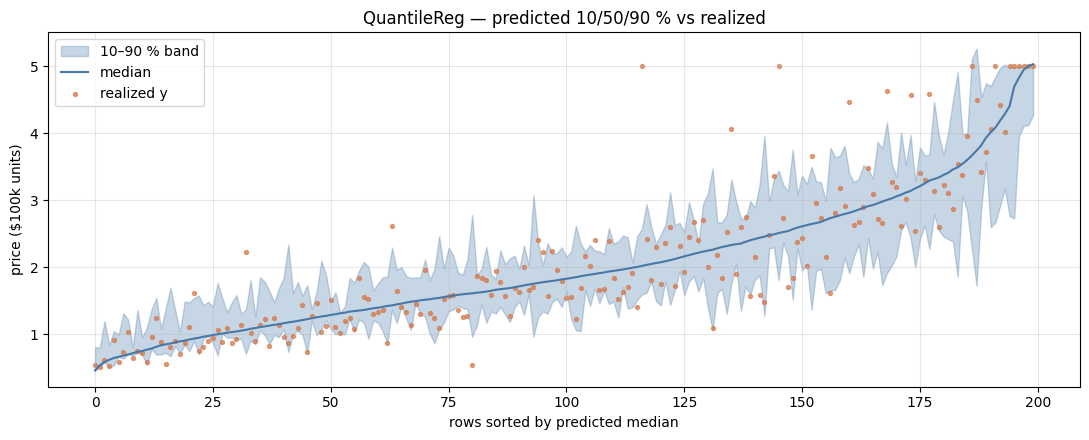

In [7]:
dist = result["qreg"]
y_oof = y[dist.ids.astype(int)]
# Sort by predicted median for a clean fan plot.
median_idx = np.argmin(np.abs(dist.taus - 0.5))
lo_idx = np.argmin(np.abs(dist.taus - 0.1))
hi_idx = np.argmin(np.abs(dist.taus - 0.9))
order = np.argsort(dist.qvals[:, median_idx])
sub = order[::20]   # 1 in 20 for legibility
xs = np.arange(sub.size)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(xs, dist.qvals[sub, lo_idx], dist.qvals[sub, hi_idx],
                alpha=0.3, color="#4878a8", label="10–90 % band")
ax.plot(xs, dist.qvals[sub, median_idx], color="#4878a8", lw=1.5,
        label="median")
ax.scatter(xs, y_oof[sub], s=8, color="#d57646", alpha=0.7,
           label="realized y")
ax.set_xlabel("rows sorted by predicted median")
ax.set_ylabel("price ($100k units)")
ax.set_title("QuantileReg — predicted 10/50/90 % vs realized")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## Reliability diagram (per bracket)

For each bracket, group rows by their predicted probability of landing
in that bracket, then plot mean predicted probability vs the empirical
hit rate. Points on the diagonal = perfectly calibrated bracket prices.

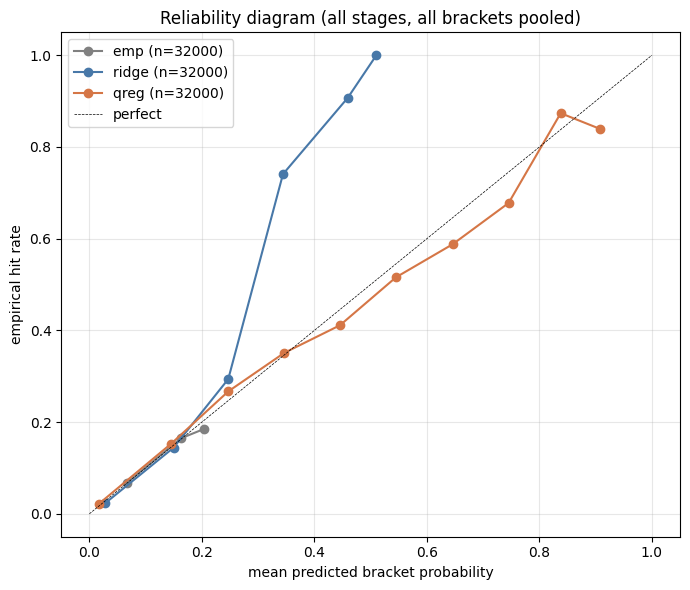

In [8]:
def reliability(dist, ladder, y_oof, n_bins=10):
    """Pool all (row, bracket) cells, bin by predicted probability,
    return (mean_pred, hit_rate, count) per bin."""
    cdf_hi = dist.cdf(ladder.edges[1:])
    cdf_lo = dist.cdf(ladder.edges[:-1])
    probs = np.clip(cdf_hi - cdf_lo, 0, 1)            # (N, B)
    bin_idx = np.searchsorted(ladder.edges, y_oof, side="right") - 1
    bin_idx = np.clip(bin_idx, 0, probs.shape[1] - 1)
    realized = np.zeros_like(probs)
    realized[np.arange(probs.shape[0]), bin_idx] = 1.0
    p_flat = probs.reshape(-1)
    r_flat = realized.reshape(-1)
    edges_p = np.linspace(0, 1, n_bins + 1)
    means, hits, counts = [], [], []
    for i in range(n_bins):
        mask = (p_flat >= edges_p[i]) & (p_flat < edges_p[i + 1] + (i == n_bins - 1))
        if mask.sum() < 5:
            continue
        means.append(p_flat[mask].mean())
        hits.append(r_flat[mask].mean())
        counts.append(int(mask.sum()))
    return np.array(means), np.array(hits), np.array(counts)


fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(["emp", "ridge", "qreg"],
                       ["gray", "#4878a8", "#d57646"], strict=True):
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    mp, hr, cnt = reliability(dist, ladder, y_oof)
    ax.plot(mp, hr, "o-", label=f"{name} (n={cnt.sum()})", color=color)
ax.plot([0, 1], [0, 1], "k--", lw=0.5, label="perfect")
ax.set_xlabel("mean predicted bracket probability")
ax.set_ylabel("empirical hit rate")
ax.set_title("Reliability diagram (all stages, all brackets pooled)")
ax.legend()
plt.tight_layout(); plt.show()

## Bracket prices for 3 held-out houses

Empirical assigns the same probabilities to every row (no features
used). Ridge spreads mass around its central prediction with one
global σ. QReg captures heteroscedasticity — narrow distributions for
easy rows, wide for hard ones.

/var/folders/f8/fdzhd8zj2v30mjn2qmtfhzb80000gn/T/ipykernel_92805/1107695206.py:11: UserWarning: ladder does not cover distribution support: worst row missed 0.1716 of mass (3/3 rows above coverage_tol=0.0001). Extend ladder edges or set strict=False to silence.
  contracts = ladder.price(pred[name])
/var/folders/f8/fdzhd8zj2v30mjn2qmtfhzb80000gn/T/ipykernel_92805/1107695206.py:11: UserWarning: ladder does not cover distribution support: worst row missed 0.5362 of mass (1/3 rows above coverage_tol=0.0001). Extend ladder edges or set strict=False to silence.
  contracts = ladder.price(pred[name])


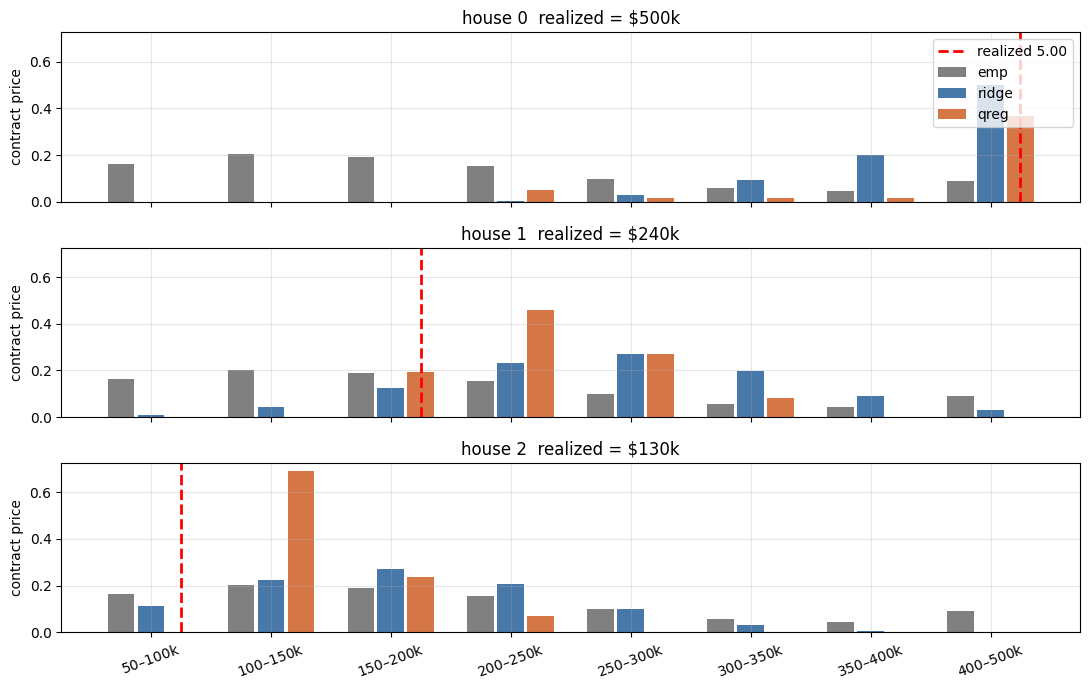

In [9]:
pred = pipeline.predict(X[:3], ids=np.arange(3),
                        timestamps=np.arange(3, dtype=float))
B = edges.shape[0] - 1
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, sharey=True)
for row_idx, ax in enumerate(axes):
    actual = y[row_idx]
    for offset, (name, color) in enumerate(
        zip(["emp", "ridge", "qreg"],
            ["gray", "#4878a8", "#d57646"], strict=True),
    ):
        contracts = ladder.price(pred[name])
        prices = contracts.fair_price.reshape(-1, B)[row_idx]
        xs = np.arange(B) + offset * 0.25
        ax.bar(xs, prices, width=0.22, color=color, label=name)
    ax.axvline(np.searchsorted(edges, actual) - 1.5, color="red",
               linestyle="--", linewidth=2, label=f"realized {actual:.2f}")
    ax.set_ylabel("contract price")
    ax.set_title(f"house {row_idx}  realized = ${actual*100:.0f}k")
    if row_idx == 0:
        ax.legend(loc="upper right")
axes[-1].set_xticks(np.arange(B) + 0.25)
axes[-1].set_xticklabels(bracket_labels, rotation=20)
plt.tight_layout(); plt.show()

## Leaderboard: wider model zoo

Score a broader set of trainers on the same data + CV. Skill is reported
vs the Empirical baseline. Anything above zero is doing real work.

In [10]:
from bracketlearn.trainers import MixtureNormals, NGBoostNormal, QuantileForest


def _score_one(stage_name, forecaster):
    p = ForecastPipeline(
        steps=[(stage_name, forecaster)],
        cv="kfold", n_folds=5, shuffle=True, random_state=0,
        refit_on_full=False,
    )
    r = p.fit_predict(X, y, ids=ids, timestamps=ts)
    return r.score(y, metrics=["crps", "log_score"])[stage_name]


leaderboard = {}
leaderboard["Empirical"] = _score_one("emp", EmpiricalDistribution())
leaderboard["Ridge+GR"] = _score_one("ridge", LiftedForecaster(
    SklearnPoint(RidgeCV()), GlobalResidual(), name="ridge",
))
leaderboard["MixtureNormals"] = _score_one("mix", MixtureNormals())
leaderboard["NGBoostNormal"] = _score_one("ngb", NGBoostNormal(
    n_estimators=200, random_seed=0,
))
leaderboard["QuantileReg"] = _score_one("qreg", QuantileReg(
    n_estimators=200, learning_rate=0.05, random_seed=0,
))
leaderboard["QuantileForest"] = _score_one("qf", QuantileForest(
    n_estimators=200, random_seed=0,
))

base_crps = leaderboard["Empirical"]["crps"]
rows = []
for name, m in leaderboard.items():
    rows.append((name, m["crps"], m.get("log_score", float("nan")),
                 1.0 - m["crps"] / base_crps))
rows.sort(key=lambda r: r[1])    # ascending CRPS

print(f"{'rank':<5}{'model':<18}{'CRPS':>10}{'log_score':>14}{'CRPSS':>10}")
print("-" * 57)
for i, (name, c, ls, sk) in enumerate(rows, 1):
    ls_s = "    n/a" if not np.isfinite(ls) else f"{ls:14.4f}"
    print(f"{i:<5}{name:<18}{c:>10.4f}{ls_s}{sk:>+10.3f}")

rank model                   CRPS     log_score     CRPSS
---------------------------------------------------------
1    QuantileReg           0.2514       -0.4010    +0.589
2    QuantileForest        0.2725       -0.3698    +0.555
3    NGBoostNormal         0.3438        0.9248    +0.438
4    Ridge+GR              0.4048        2.5319    +0.339
5    Empirical             0.6120        1.3754    +0.000
6    MixtureNormals       23.2072        2.9521   -36.921


## Bridge to classical ML: point-forecast benchmark

Probabilistic models can be collapsed to a point forecast by taking the
mean (or median, or mode) of the predicted distribution. Once you have
a single number per row, you can use the metrics regression people
already know — RMSE, MAE, MAPE — and compare against a sklearn
regressor trained with the same CV.

This is the "OK but does it beat sklearn?" check.

rank model                           RMSE       MAE
---------------------------------------------------
1    LightGBM                      0.5136    0.3455
2    QuantileReg (→mean)           0.5426    0.3698
3    Empirical (→mean)             1.1468    0.9137
4    sklearn RidgeCV               1.3863    0.5470
5    Ridge+GR (→mean)              1.4247    0.5477
6    MixtureNormals (→mean)      243.1488  176.2672


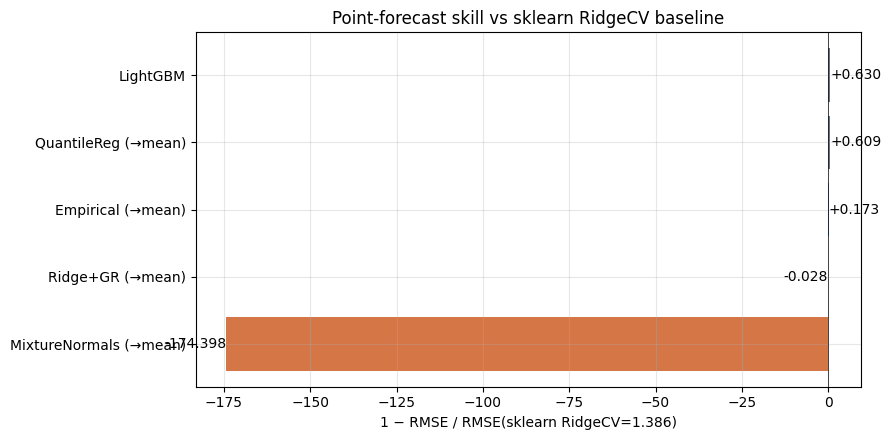

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold

from bracketlearn.score import to_point

# Refit each leaderboard pipeline; collapse OOF dist to mean → RMSE/MAE.
def _dist_to_point_metrics(stage_name, forecaster):
    p = ForecastPipeline(
        steps=[(stage_name, forecaster)],
        cv="kfold", n_folds=5, shuffle=True, random_state=0,
        refit_on_full=False,
    )
    r = p.fit_predict(X, y, ids=ids, timestamps=ts)
    dist = r[stage_name]
    y_oof = y[dist.ids.astype(int)]
    mu = to_point(dist, how="mean")
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_oof, mu))),
        "MAE":  float(mean_absolute_error(y_oof, mu)),
    }


# Two classical-ML baselines using the same k-fold split (no
# distributional output — just RMSE / MAE per row of the OOF predict).
def _sklearn_oof_metrics(model):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    oof_pred = np.empty_like(y)
    for tr, te in kf.split(X):
        m = type(model)(**model.get_params())
        m.fit(X[tr], y[tr])
        oof_pred[te] = m.predict(X[te])
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y, oof_pred))),
        "MAE":  float(mean_absolute_error(y, oof_pred)),
    }


from lightgbm import LGBMRegressor

point_lb = {
    # Probabilistic → mean.
    "Empirical (→mean)":      _dist_to_point_metrics("e", EmpiricalDistribution()),
    "Ridge+GR (→mean)":       _dist_to_point_metrics("r", LiftedForecaster(
        SklearnPoint(RidgeCV()), GlobalResidual(), name="r",
    )),
    "MixtureNormals (→mean)": _dist_to_point_metrics("m", MixtureNormals()),
    "QuantileReg (→mean)":    _dist_to_point_metrics("q", QuantileReg(
        n_estimators=200, learning_rate=0.05, random_seed=0,
    )),
    # Classical regressors (no distribution at all).
    "sklearn RidgeCV":        _sklearn_oof_metrics(RidgeCV()),
    "LightGBM":               _sklearn_oof_metrics(LGBMRegressor(
        n_estimators=200, learning_rate=0.05, verbose=-1, random_state=0,
    )),
}

rows_pt = sorted(point_lb.items(), key=lambda kv: kv[1]["RMSE"])
print(f"{'rank':<5}{'model':<26}{'RMSE':>10}{'MAE':>10}")
print("-" * 51)
for i, (name, m) in enumerate(rows_pt, 1):
    print(f"{i:<5}{name:<26}{m['RMSE']:>10.4f}{m['MAE']:>10.4f}")

# Skill bars: RMSE vs the sklearn baseline.
sk_rmse = point_lb["sklearn RidgeCV"]["RMSE"]
names_pt = [r[0] for r in rows_pt if r[0] != "sklearn RidgeCV"]
skills_pt = [1 - r[1]["RMSE"]/sk_rmse for r in rows_pt if r[0] != "sklearn RidgeCV"]
fig, ax = plt.subplots(figsize=(9, 4.5))
colors_pt = ["#4878a8" if s > 0 else "#d57646" for s in skills_pt]
ax.barh(names_pt, skills_pt, color=colors_pt)
ax.axvline(0, color="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel(f"1 − RMSE / RMSE(sklearn RidgeCV={sk_rmse:.3f})")
ax.set_title("Point-forecast skill vs sklearn RidgeCV baseline")
for i, s in enumerate(skills_pt):
    ax.text(s + (0.005 if s > 0 else -0.005), i, f"{s:+.3f}",
            va="center", ha="left" if s > 0 else "right")
plt.tight_layout(); plt.show()

Skill bars for the **distributional** leaderboard:

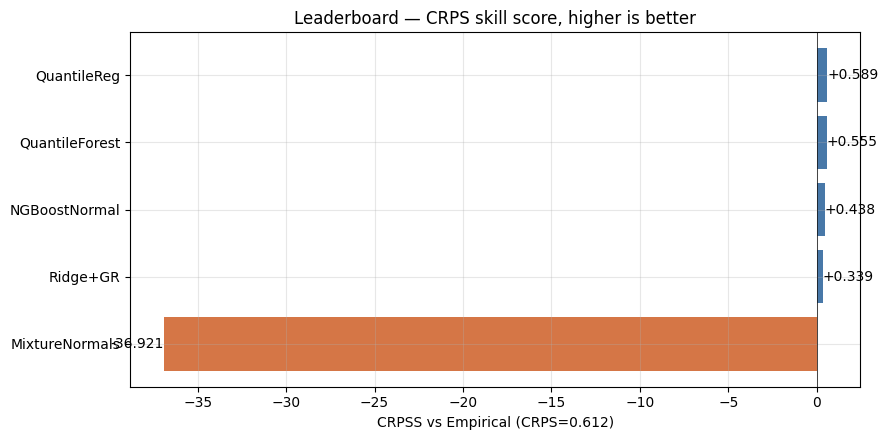

In [12]:
names = [r[0] for r in rows if r[0] != "Empirical"]
skills = [r[3] for r in rows if r[0] != "Empirical"]
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#4878a8" if s > 0 else "#d57646" for s in skills]
ax.barh(names, skills, color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel(f"CRPSS vs Empirical (CRPS={base_crps:.3f})")
ax.set_title("Leaderboard — CRPS skill score, higher is better")
for i, s in enumerate(skills):
    ax.text(s + (0.005 if s > 0 else -0.005), i,
            f"{s:+.3f}", va="center",
            ha="left" if s > 0 else "right")
plt.tight_layout(); plt.show()